# 🎬 **About Dataset**

## 📖 **Background**  
What can we say about the success of a movie before it is released? Are there certain companies (like Pixar 🐭✨) that have found a consistent formula? Given that major films costing over $100 million 💸 to produce can still flop, this question is more important than ever to the industry. Film aficionados might have different interests. Can we predict which films will be highly rated ⭐, whether or not they are a commercial success?  

This dataset offers a great starting point to explore these questions, with data on the plot, cast, crew, budget, and revenues of several thousand films 🎥.

---

## 🔄 **Data Source Transfer Summary**  
Kaggle has removed the original version of this dataset per a DMCA takedown request from IMDB. To minimize the impact, it was replaced with a similar dataset from The Movie Database (TMDb) in compliance with their terms of use.

### 🎉 **Improvements in the New Dataset:**  
- **🔗 Full Credits:** Contains full credits for both the cast and crew.  
- **🕵️‍♂️ Actor Order:** Actors are now listed in the order they appear in the credits.  
- **💰 Revenue Accuracy:** Revenue figures are more current (e.g., accurate data for *Avatar*).  
- **🚫 Bad Entries Removed:** Some inaccurate entries have been excluded.  

### ⚠️ **Things to Note:**  
- Several new columns contain JSON data.  
- Runtime and other fields may differ in consistency across datasets.  
- Data is user-filled, so expect some variation in keywords, genres, and ratings.

---

## 📊 **Data Source Transfer Details**

### 🆕 **New Columns:**  
- homepage  
- id  
- original_title  
- overview  
- popularity  
- production_companies  
- production_countries  
- release_date  
- spoken_languages  
- status  
- tagline  
- vote_average  

### ❌ **Lost Columns:**  
- actor_1_facebook_likes  
- actor_2_facebook_likes  
- actor_3_facebook_likes  
- aspect_ratio  
- cast_total_facebook_likes  
- color  
- content_rating  
- director_facebook_likes  
- facenumber_in_poster  
- movie_facebook_likes  
- movie_imdb_link  
- num_critic_for_reviews  
- num_user_for_reviews  

---

## ❓ **Open Questions About the Data**
- Are the budgets and revenues all in USD? Do they consistently show global revenues?  
- Are zeros in the budget field missing values? (In previous datasets, zeros likely represented missing data, especially for small-budget films).  

Any findings on these questions can be helpful for your fellow Kagglers! 🌟

---

## 💡 **Inspiration**
- Can you categorize the films by type (e.g., animated 🐾 or not)?  
- How distinct is the divide between major film studios 🏢 and independent producers?  

Clustering analysis may reveal patterns 📊 or uncover more complex relationships.


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.stem.porter import PorterStemmer
import pickle
from wordcloud import WordCloud
import ast
nltk.download('stopwords')
plt.style.use('seaborn-v0_8')
%matplotlib inline


[nltk_data] Downloading package stopwords to C:\Users\Sajjad
[nltk_data]     Khan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Load datasets
df_movies = pd.read_csv('Dataset/tmdb_5000_movies.csv')
df_credits = pd.read_csv('Dataset/tmdb_5000_credits.csv')
df = df_movies.merge(df_credits, on='title')
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(2)

Dataset Shape: (4809, 23)
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'movie_id', 'cast', 'crew']


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


Missing Values:
 budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64


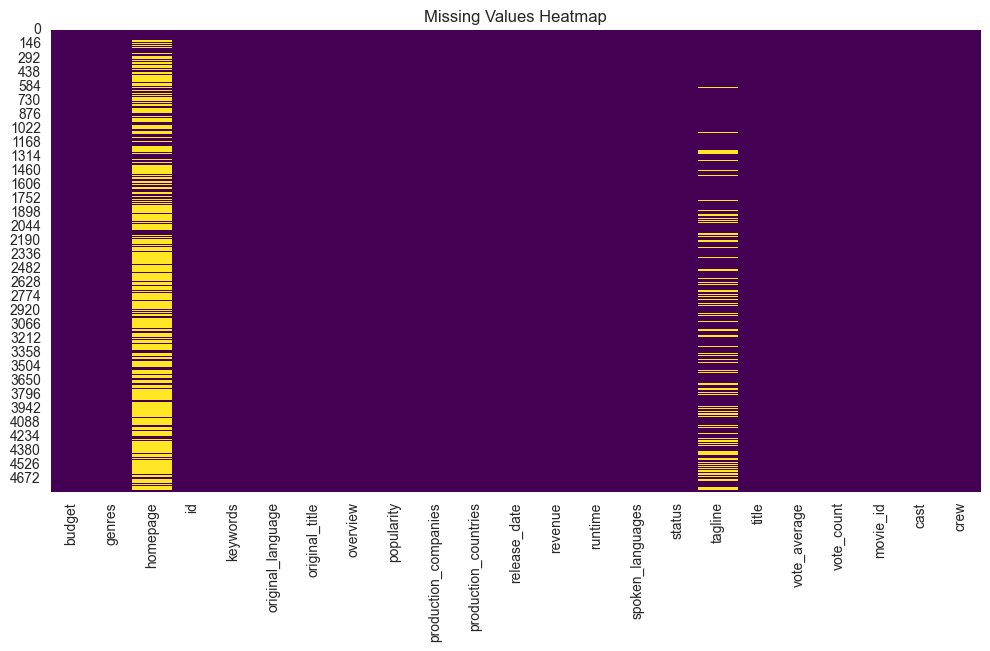

In [6]:
# Basic statistics
df.describe()

# Check missing values
print('Missing Values:\n', df.isnull().sum())
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [7]:
# Drop rows with missing critical columns
df = df.dropna(subset=['overview', 'genres', 'keywords', 'cast', 'crew'])

In [8]:
# Check duplicates
print('Duplicate Rows:', df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 0


In [9]:
# Verify budget and revenue zeros
print('Zero Budget Count:', (df['budget'] == 0).sum())
print('Zero Revenue Count:', (df['revenue'] == 0).sum())
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

Zero Budget Count: 1039
Zero Revenue Count: 1427


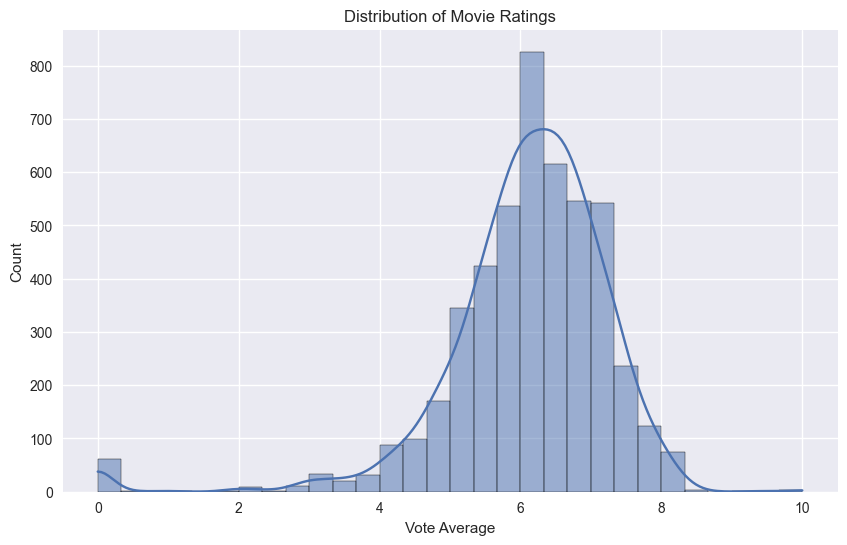

In [10]:

# Distribution of vote_average
plt.figure(figsize=(10, 6))
sns.histplot(df['vote_average'], bins=30, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.show()

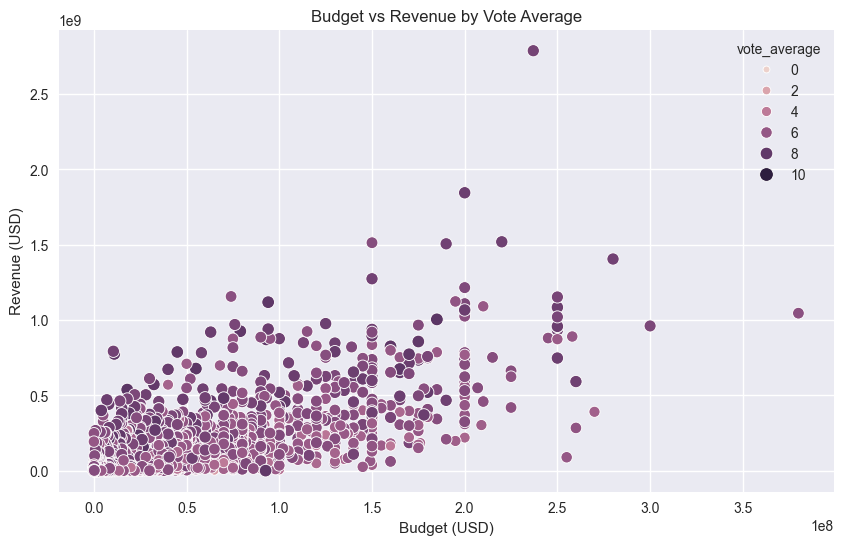

In [11]:
# Budget vs Revenue Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=df, hue='vote_average', size='vote_average')
plt.title('Budget vs Revenue by Vote Average')
plt.xlabel('Budget (USD)')
plt.ylabel('Revenue (USD)')
plt.show()

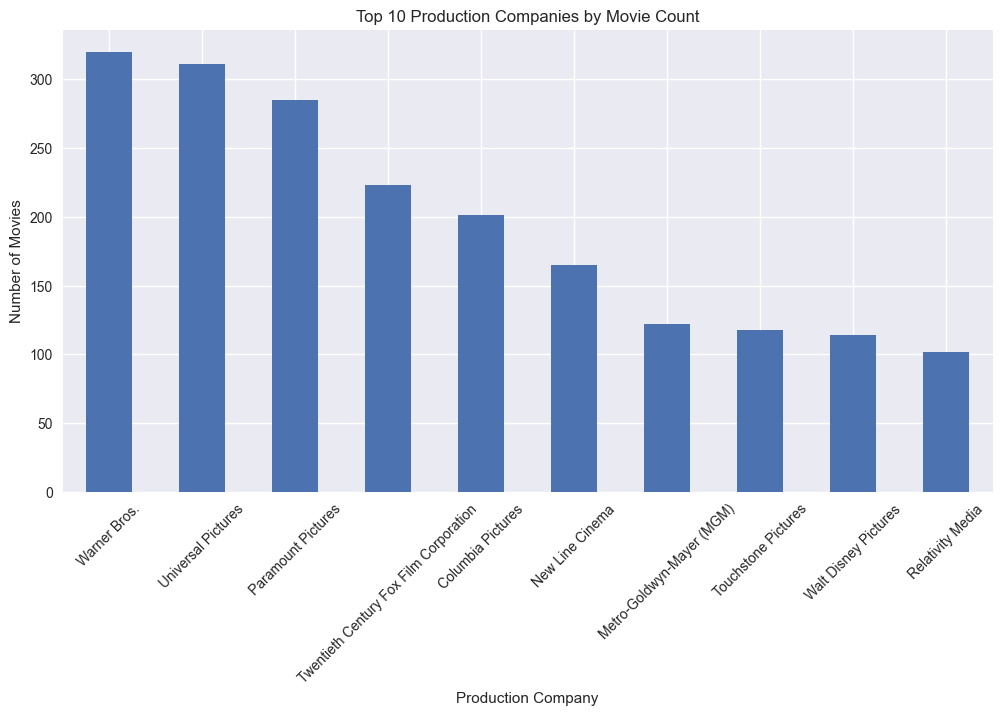

In [12]:
# Top 10 Production Companies
def extract_production_companies(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)]
    except:
        return []
df['production_companies_list'] = df['production_companies'].apply(extract_production_companies)
prod_counts = pd.Series([comp for sublist in df['production_companies_list'] for comp in sublist]).value_counts()
plt.figure(figsize=(12, 6))
prod_counts.head(10).plot(kind='bar')
plt.title('Top 10 Production Companies by Movie Count')
plt.xlabel('Production Company')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

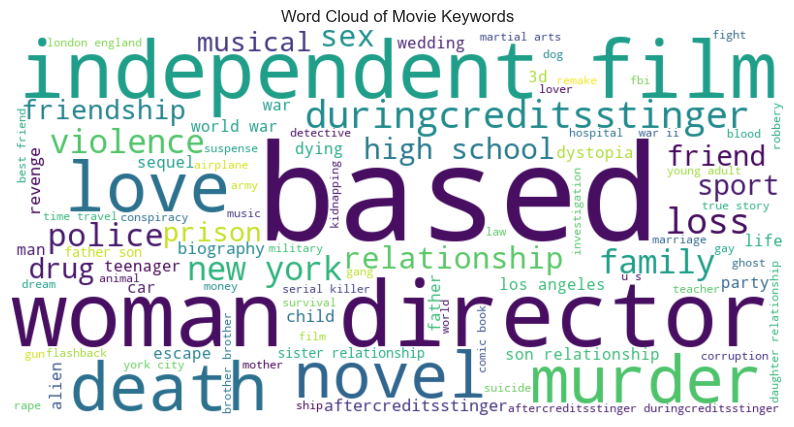

In [13]:
# Word Cloud for Keywords
def extract_keywords(text):
    try:
        return ' '.join([item['name'] for item in ast.literal_eval(text)])
    except:
        return ''
keywords_text = ' '.join(df['keywords'].apply(extract_keywords))
wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(keywords_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Keywords')
plt.show()

In [14]:
# Select relevant columns
df = df[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]


In [15]:
# Convert nested data to lists
def convert_to_list(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)]
    except:
        return []


In [16]:
# Extract top 3 cast members
def convert_cast(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)[:3]]
    except:
        return []

In [17]:
# Extract director
def fetch_director(text):
    try:
        for item in ast.literal_eval(text):
            if item['job'] == 'Director':
                return [item['name']]
        return []
    except:
        return []

In [18]:
# Apply conversions
df['genres'] = df['genres'].apply(convert_to_list)
df['keywords'] = df['keywords'].apply(convert_to_list)
df['cast'] = df['cast'].apply(convert_cast)
df['crew'] = df['crew'].apply(fetch_director)
df['overview'] = df['overview'].apply(lambda x: x.split() if isinstance(x, str) else [])

In [19]:
# Remove spaces
df['genres'] = df['genres'].apply(lambda x: [i.replace(' ', '') for i in x])
df['keywords'] = df['keywords'].apply(lambda x: [i.replace(' ', '') for i in x])
df['cast'] = df['cast'].apply(lambda x: [i.replace(' ', '') for i in x])
df['crew'] = df['crew'].apply(lambda x: [i.replace(' ', '') for i in x])

In [20]:
# Combine features into tags
df['tags'] = df['overview'] + df['genres'] + df['keywords'] + df['cast'] + df['crew']
df = df[['movie_id', 'title', 'tags']]
df['tags'] = df['tags'].apply(lambda x: ' '.join(x).lower())

In [21]:
# Apply stemming
ps = PorterStemmer()
def stem(text):
    return ' '.join([ps.stem(word) for word in text.split()])
df['tags'] = df['tags'].apply(stem)
df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."


In [22]:
# Vectorize tags using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vector = tfidf.fit_transform(df['tags']).toarray()
similarity = cosine_similarity(vector)

In [23]:
# Recommendation function
def recommend(movie):
    try:
        movie_index = df[df['title'] == movie].index[0]
        distances = similarity[movie_index]
        movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
        print(f"Recommendations for '{movie}':")
        for i in movies_list:
            print(f"- {df.iloc[i[0]]['title']} (Similarity: {i[1]:.3f})")
    except IndexError:
        print(f"Movie '{movie}' not found in the dataset.")
recommend('The Dark Knight Rises')


Recommendations for 'The Dark Knight Rises':
- The Dark Knight (Similarity: 0.460)
- Batman Returns (Similarity: 0.406)
- Batman Forever (Similarity: 0.332)
- Batman Begins (Similarity: 0.322)
- Batman (Similarity: 0.315)


In [24]:
# Qualitative evaluation
test_movies = ['Avatar', 'The Dark Knight Rises', 'Inception', 'Toy Story', 'The Godfather']
for movie in test_movies:
    print('\n')
    recommend(movie)



Recommendations for 'Avatar':
- Aliens (Similarity: 0.252)
- Falcon Rising (Similarity: 0.226)
- Battle: Los Angeles (Similarity: 0.194)
- Aliens vs Predator: Requiem (Similarity: 0.188)
- Apollo 18 (Similarity: 0.177)


Recommendations for 'The Dark Knight Rises':
- The Dark Knight (Similarity: 0.460)
- Batman Returns (Similarity: 0.406)
- Batman Forever (Similarity: 0.332)
- Batman Begins (Similarity: 0.322)
- Batman (Similarity: 0.315)


Recommendations for 'Inception':
- Don Jon (Similarity: 0.181)
- The East (Similarity: 0.160)
- 12 Rounds (Similarity: 0.155)
- Hesher (Similarity: 0.154)
- Premium Rush (Similarity: 0.139)


Recommendations for 'Toy Story':
- Toy Story 3 (Similarity: 0.512)
- Toy Story 2 (Similarity: 0.456)
- Small Soldiers (Similarity: 0.189)
- For Your Consideration (Similarity: 0.182)
- The 41–Year–Old Virgin Who Knocked Up Sarah Marshall and Felt Superbad About It (Similarity: 0.144)


Recommendations for 'The Godfather':
- Desert Dancer (Similarity: 0.433)
-

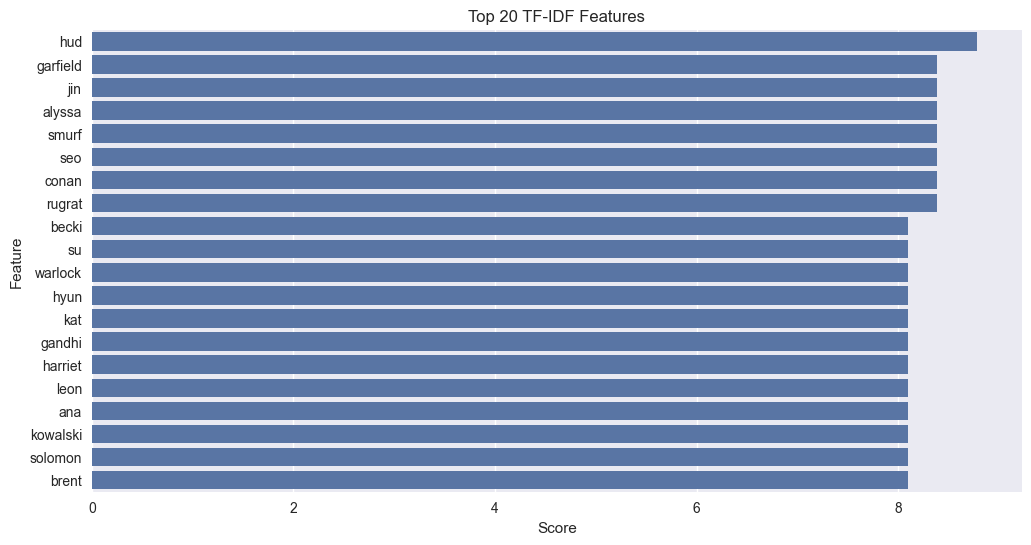

In [25]:
# Feature importance
feature_names = tfidf.get_feature_names_out()
top_features = pd.DataFrame({'Feature': feature_names, 'Score': tfidf.idf_}).sort_values('Score', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=top_features.head(20))
plt.title('Top 20 TF-IDF Features')
plt.show()

In [26]:

# Save data and model
pickle.dump(df, open('movie_list.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
print('Model and data saved successfully.')

Model and data saved successfully.
